# Retail Data Analysis – Visualization & Insights

This notebook is responsible for:
- Calling Flask API endpoints
- Converting JSON responses into Pandas DataFrames
- Visualizing business insights using charts


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [3]:
sns.set_theme(style='darkgrid')


In [4]:
BASE_URL = "http://127.0.0.1:5000"


In [5]:
resp = requests.get(f"{BASE_URL}/top-customers")
data = resp.json()


In [6]:
df_customers = pd.DataFrame(data)
df_customers


,city,customer_id,customer_name,gender,monthly_spending,preferred_branch,top_products,total_orders,total_spent
0,Giza,10099,Khaled Kamel,Male,"{'2022-02': 104413.38, '2022-03': 75827.7, '20...",Haram Branch,"[{'product_name': 'Furniture Product 4043', 'q...",9,95556.26
1,Ismailia,8636,Mariam Youssef,Female,"{'2022-01': 126242.54999999999, '2022-04': 337...",El Maadi Degla Branch,"[{'product_name': 'Sports Product 16738', 'qua...",10,93448.75
2,Alexandria,7664,Ahmed Kamel,Male,"{'2022-07': 59171.149999999994, '2022-09': 901...",Talkha Branch,"[{'product_name': 'Beauty Product 49015', 'qua...",8,90775.39
3,Mansoura,7287,Mariam Mahmoud,Female,"{'2022-04': 25312.350000000002, '2022-10': 790...",New Fayoum Branch,"[{'product_name': 'Stationery Product 35819', ...",8,84686.83
4,Giza,11334,Aya Ibrahim,Female,"{'2022-03': 68726.0, '2022-07': 33063.04999999...",Shibin El Qanater Branch,"[{'product_name': 'Groceries Product 11282', '...",9,80320.33


In [7]:
plt.figure(figsize=(8, 5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

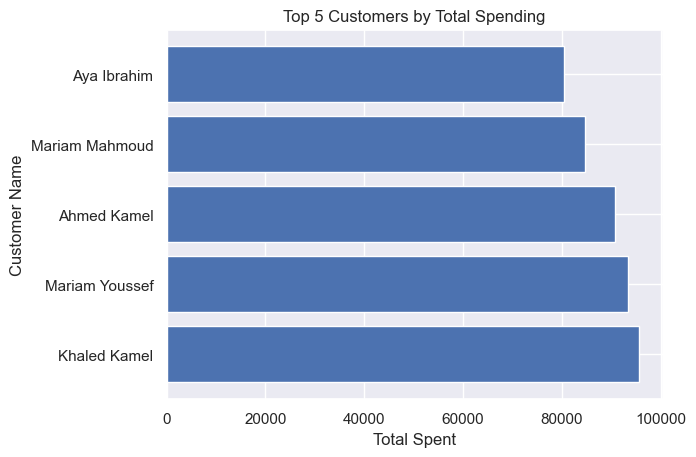

In [8]:
plt.barh(
    df_customers["customer_name"],
    df_customers["total_spent"]
)
plt.title("Top 5 Customers by Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Customer Name")
plt.grid(True)
plt.show()



## Best Selling Products

In [9]:
resp = requests.get(f"{BASE_URL}/best-products")
data = resp.json()

df_products = pd.DataFrame(data)
df_products



,product_name,total_quantity
0,Stationery Product 928,54
1,Furniture Product 2442,48
2,Electronics Product 6233,46
3,Home Appliances Product 36958,45
4,Groceries Product 45306,45


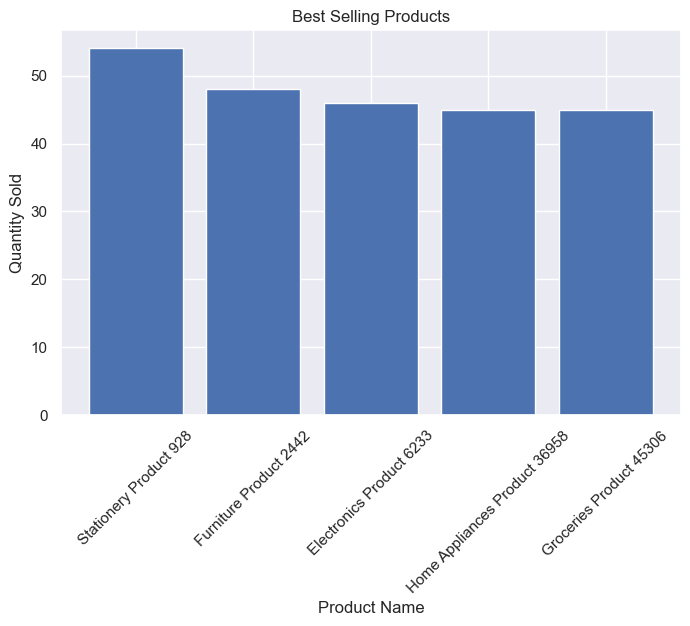

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(
    df_products["product_name"],
    df_products["total_quantity"]
)
plt.title("Best Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



In [11]:
resp = requests.get(f"{BASE_URL}/branch-revenue")
data = resp.json()

df_branch = pd.DataFrame(data)
df_branch


,branch_name,total_revenue
0,Abbasia Branch,9148565.04
1,Farshout Branch,9012150.04
2,Shibin El Kom Branch,8779901.01
3,Ashmoun Branch,8747262.61
4,Fayoum Branch,8677125.58
...,...,...
195,El Minya New Branch,6177499.71
196,Kom Ombo Branch,6170107.46
197,New Ismailia Branch,6159661.86
198,Farafra Branch,6059108.71


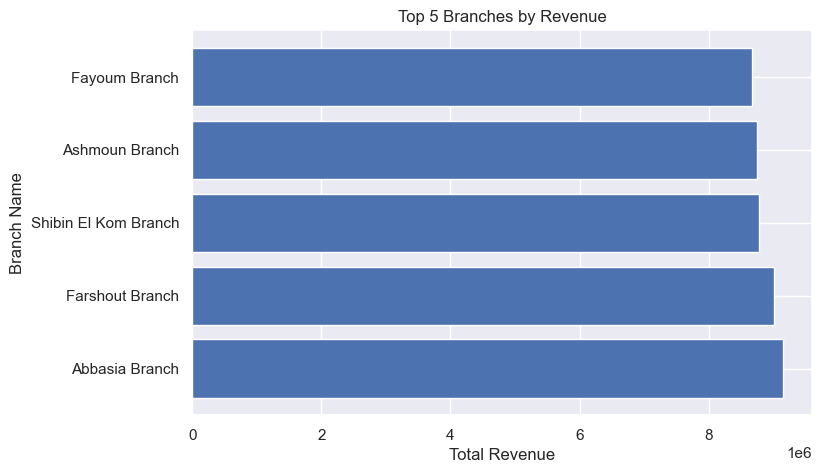

In [19]:
df_branch_sorted = df_branch.sort_values(
    by="total_revenue",
    ascending=False
).head(5)

plt.figure(figsize=(8, 5))
plt.barh(
    df_branch_sorted["branch_name"],
    df_branch_sorted["total_revenue"]
)
plt.title("Top 5 Branches by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Branch Name")
plt.grid(True)
plt.show()
